Data Analysis Real World Use Case

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for better interactive visualization
import plotly.graph_objects as go
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os


In [3]:
files=os.listdir('F:\Python Practice\Data Analyst Project\Developed Projects\Covid-19')
files

['country_wise_latest.csv',
 'covid_19_clean_complete.csv',
 'day_wise.csv',
 'full_grouped.csv',
 'usa_country_wise.csv',
 'worldometer_data.csv']

In [4]:
### lets create a function to make our task simpler as we have to read data aggain & again 
def read_data(path,filename):
    return pd.read_csv(path+'/'+filename)
    

In [5]:
path='F:\Python Practice\Data Analyst Project\Developed Projects\Covid-19'
world_data=read_data(path,'worldometer_data.csv')

In [6]:
day_wise=read_data(path,files[2])

In [7]:
group_data=read_data(path,files[3])

In [8]:
usa_data=read_data(path,files[4])

In [9]:
province_data=read_data(path,files[1])

In [10]:
province_data.shape

(49068, 10)

In [11]:
world_data.columns

Index(['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases',
       'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered',
       'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop',
       'TotalTests', 'Tests/1M pop', 'WHO Region'],
      dtype='object')

In [12]:
import plotly.express as px

In [13]:
columns=['TotalCases','TotalDeaths','TotalRecovered','ActiveCases']

for i in columns:
    fig = px.treemap(world_data.iloc[0:20],values=i,path=['Country/Region'],title='Treemap Repr of Different countries w.r.t of do ifferent countries')
    fig.show()

In [14]:
day_wise.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


In [15]:
day_wise.columns

Index(['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases',
       'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'No. of countries'],
      dtype='object')

In [16]:
px.line(day_wise,x='Date',y = ['Confirmed', 'Deaths', 'Recovered', 'Active'], title = 'Covid Cases wrt Date',template='plotly_dark')

In [17]:

pop_test_ratio= world_data['Population']/world_data['TotalTests'].iloc[1:20]

In [18]:
fig = px.bar(world_data.iloc[0:20],x='Country/Region',y =pop_test_ratio.iloc[0:20],color='Country/Region', title='Pop to tests done ratio')
fig.show()

In [19]:
world_data.columns

Index(['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases',
       'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered',
       'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop',
       'TotalTests', 'Tests/1M pop', 'WHO Region'],
      dtype='object')

In [20]:
px.bar(world_data.iloc[0:20],x='Country/Region',y=['Serious,Critical','TotalDeaths','TotalRecovered','ActiveCases','TotalCases'])

In [21]:
world_data.sort_values(by='TotalDeaths',ascending=False)

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
5,Mexico,North America,1.290662e+08,462690,6590.0,50517.0,819.0,308848.0,4140.0,103325.0,3987.0,3585.0,391.0,1056915.0,8189.0,Americas
11,UK,Europe,6.792203e+07,308134,NaN,46413.0,NaN,NaN,NaN,NaN,73.0,4537.0,683.0,17515234.0,257873.0,Europe
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,Saint Kitts and Nevis,North America,5.323700e+04,17,NaN,NaN,NaN,16.0,NaN,1.0,NaN,319.0,NaN,1146.0,21526.0,Americas
203,Greenland,North America,5.678000e+04,14,NaN,NaN,NaN,14.0,NaN,0.0,NaN,247.0,NaN,5977.0,105266.0,Europe
205,Caribbean Netherlands,North America,2.624700e+04,13,NaN,NaN,NaN,7.0,NaN,6.0,NaN,495.0,NaN,424.0,16154.0,NaN
206,Falkland Islands,South America,3.489000e+03,13,NaN,NaN,NaN,13.0,NaN,0.0,NaN,3726.0,NaN,1816.0,520493.0,NaN


In [22]:
fig = px.bar(world_data.sort_values(by='ActiveCases',ascending=False).iloc[0:40],y='Country/Region',x='ActiveCases',color='ActiveCases',text='ActiveCases')
fig.update_layout(template='plotly_dark', title='Top 40 Countries of Active Cases')
fig.show()


In [23]:
fig = px.bar(world_data.sort_values(by='TotalDeaths',ascending=False).iloc[0:40],y='Country/Region',x='TotalDeaths',color='TotalDeaths',text='TotalDeaths')
fig.update_layout(template='plotly_dark', title='Top 40 Countries of total Death cases')
fig.show()

In [24]:
fig = px.bar(world_data.sort_values(by='TotalRecovered',ascending=False).iloc[0:40],y='Country/Region',x='TotalRecovered',color='TotalRecovered',text='TotalRecovered')
fig.update_layout(template='plotly_dark', title='Top 20 Countries of Total Recovered cases')
fig.show()

In [25]:
labels = world_data[0:15]['Country/Region'].values
cases = ['TotalRecovered','TotalDeaths','TotalCases', 'ActiveCases']
for i in cases:
    pie_chart=px.pie(world_data.iloc[0:15],values=i,names=labels,hole=0.5, title='{}  recorded w.r.t to WHO region of 15 worst affected countries'.format(i))
    pie_chart.show()

In [26]:
world_data.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [27]:
death_to_confirmed = world_data['TotalDeaths']/world_data['TotalCases']

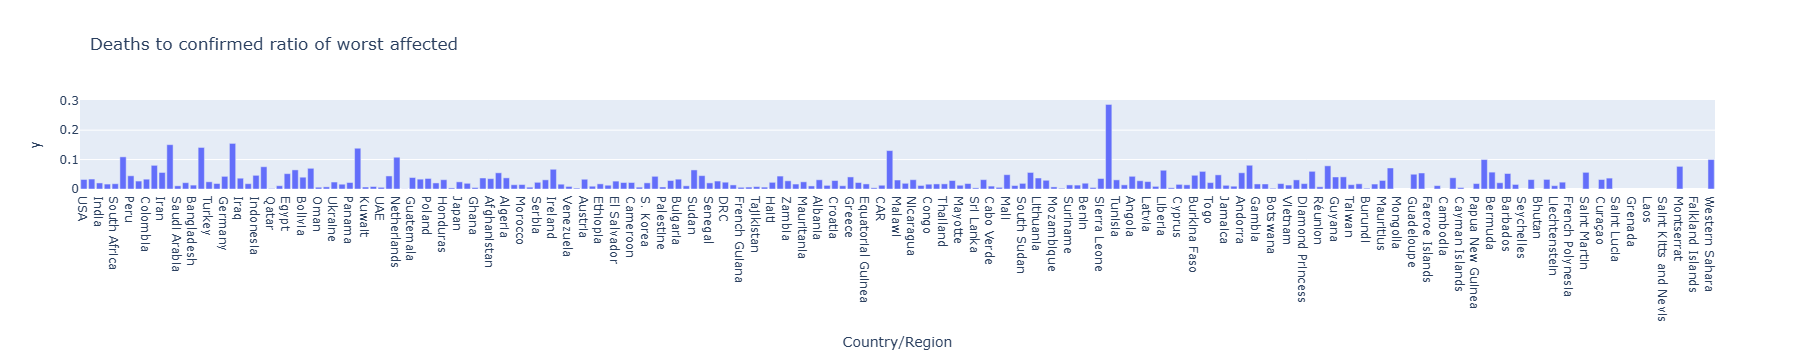

In [28]:
px.bar(world_data,x='Country/Region', y= death_to_confirmed, title ='Deaths to confirmed ratio of worst affected')

In [29]:
deaths_to_recovered = world_data['TotalDeaths']/world_data['TotalRecovered']

In [30]:
deaths_to_recovered

0      0.063184
1      0.048174
2      0.030230
3      0.021595
4      0.024796
         ...   
204    0.100000
205         NaN
206         NaN
207         NaN
208    0.125000
Length: 209, dtype: float64

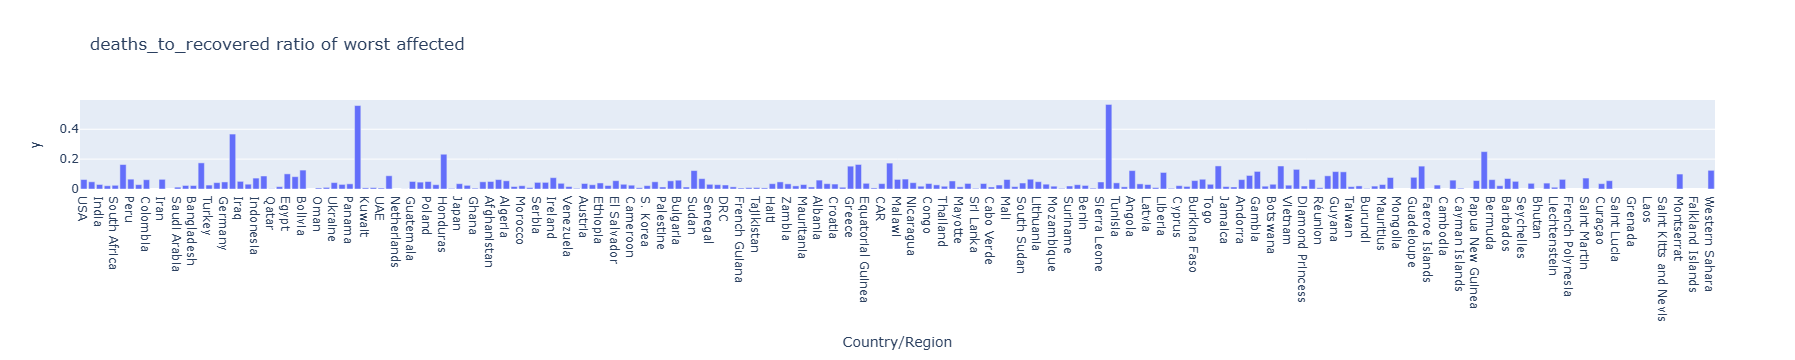

In [31]:
px.bar(world_data,x='Country/Region', y= deaths_to_recovered, title ='deaths_to_recovered ratio of worst affected')

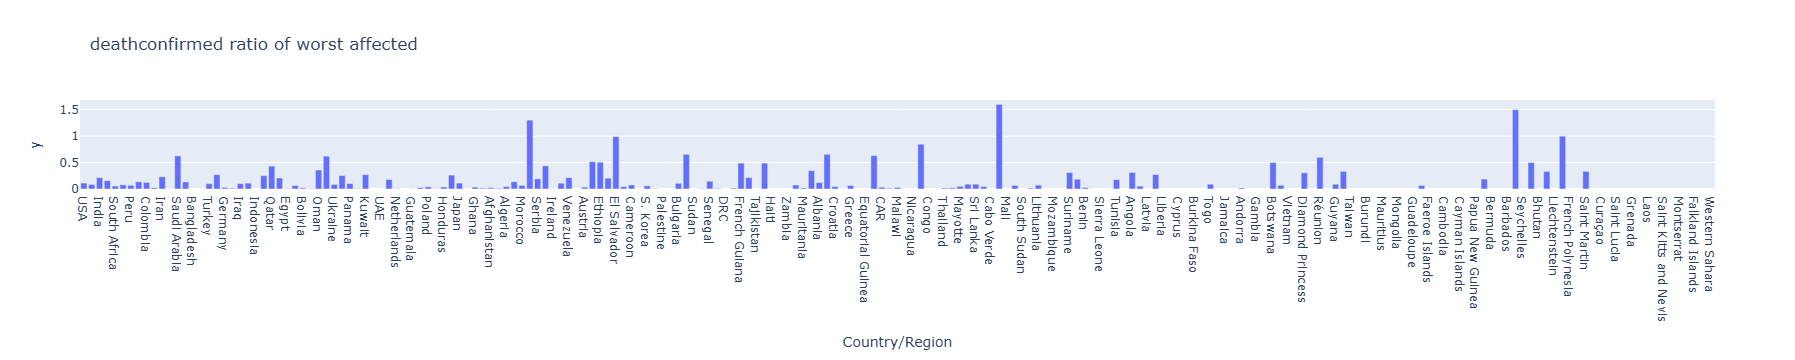

In [32]:
serious_to_deaths = world_data['Serious,Critical']/world_data['TotalDeaths']
px.bar(world_data,x='Country/Region', y= serious_to_deaths, title ='deathconfirmed ratio of worst affected')

In [33]:
group_data.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [34]:
from plotly.subplots import make_subplots

In [45]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def country_visualization(df, country):
    # Filter data for the given country
    data = df[df['Country/Region'] == country]
    data2 = data.loc[:, ['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active']]

    # Create subplots (1 row, 4 columns)
    fig = make_subplots(
        rows=1, cols=4,
        subplot_titles=('Confirmed', 'Deaths', 'Recovered', 'Active')
    )

    # Add traces (note: use col, not cols)
    fig.add_trace(
        go.Scatter(name='Confirmed', x=data2['Date'], y=data2['Confirmed']),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(name='Deaths', x=data2['Date'], y=data2['Deaths']),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(name='Recovered', x=data2['Date'], y=data2['Recovered']),
        row=1, col=3
    )
    fig.add_trace(
        go.Scatter(name='Active', x=data2['Date'], y=data2['Active']),
        row=1, col=4
    )

    # Update layout
    fig.update_layout(
        height=600,
        width=1000,
        title_text=f'Date vs Recorded cases of {country}',
        template='plotly_dark'
    )

    return fig


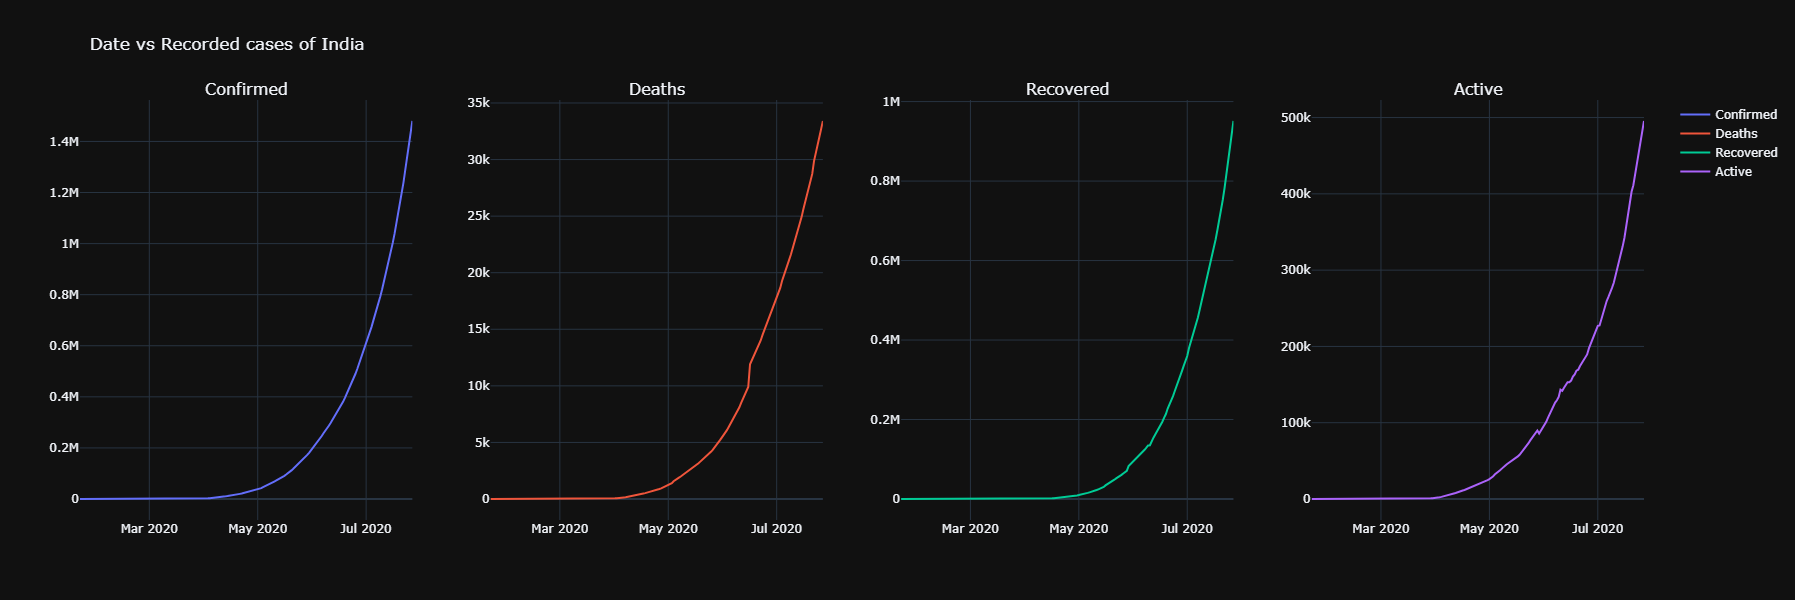

In [46]:
country_visualization(group_data,'India')